#### 𝗚𝗥𝗢𝗨𝗣 𝟱 - 𝗕𝗦𝗜𝗧-𝟮𝗔

Members: 
1. Domingo, Mario Jr. C.
2. Daclison, Trisha Jamaica U.
3. Dela Cruz, Bic Julian

#### **1. Background of the Study**

**Title:** Forecasting Population Growth Trends in the Philippines (2020–2025)

**Source:** Philippines Population Projection Dataset (2020–2025), Admin3 / PSA (psa.gov.ph)

---

**Brief Description of Dataset**
- **Size:** 1,635 rows × 12 columns  
- **Unit of analysis:** One row = one city/municipality  
- **Time coverage:** July 2020 to July 2025 (midyear population, levels)

**Main Columns**
- `Region` — Administrative region name  
- `Region_pcode` — Region code  
- `Province` — Province name  
- `Province_pcode` — Province code  
- `Municipality_City` — City/Municipality name  
- `Mun_pcode` — City/Municipality code  
- `July2020` … `July2025` — Projected midyear population (levels)

> The dataset provides municipal/city population projections based on the 2015 Census and PSA growth-rate estimates.

---

**Selected Features (Independent Variables)**
1. **Region_pcode** – encoded region code  
   - Categorical identifier for the region of each city / municipality.

2. **Province_pcode** – encoded province code  
   - Categorical identifier for the province.

3. **Municipality_City** – encoded municipality / city name  
   - Categorical identifier for the specific LGU.

4. **Year** – encoded calendar year (2020–2025)  
   - Represents the time dimension for each population observation.


**Target / Label (Dependent Variable)**
- **PopulationChange** – binary target indicating annual population change for each municipality-year:

  - `1` → the population **increased** compared with the previous year  
  - `0` → the population **did not increase** or **decreased** compared with the previous year  

---

**Objectives:**
The study aims to model and classify **annual population change** of Philippine cities and municipalities from 2020 to 2025 using a Random Forest classifier.

1. **Classify annual population change**  
   - Predict, for each municipality and year, whether the population will **increase (PopulationChange = 1)** or **not increase / decrease (PopulationChange = 0)** based on region, province, municipality, and year.

2. **Identify spatial and temporal patterns in population dynamics**  
   - Analyze which features (region, province, municipality, year) contribute most to predicting `PopulationChange` by examining feature importances from the Random Forest model.

3. **Assess the model’s performance**  
   - Evaluate how well the model predicts population change using metrics such as **accuracy, precision, recall, F1-score, and the classification report / confusion matrix**, with special attention to how well the model detects the less frequent **no-increase (0)** cases.

#### **2. Data Collection/Loading**

In [163]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the Excel sheet into a DataFrame
df = pd.read_excel("Philippines Population Projection dataset (2020–2025).xlsx")

# Display the first 10 rows
df.head(10)


,Region,Region_pcode,Province,Province_pcode,Municipality_City,Mun_Pcode,July2020,July2021,July2022,July2023,July2024,July2025
0,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Adams,PH012801000,1823,1827,1830,1833,1834,1835
1,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bacarra,PH012802000,32778,32850,32908,32951,32979,32994
2,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Badoc,PH012803000,32218,32299,32365,32418,32456,32480
3,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bangui,PH012804000,14954,14993,15024,15049,15067,15079
4,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,City of Batac,PH012805000,56248,56389,56504,56595,56661,56702
5,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Burgos,PH012806000,9948,9970,9987,10000,10009,10013
6,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Carasi,PH012807000,1644,1658,1672,1684,1696,1708
7,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Currimao,PH012808000,12419,12451,12477,12498,12513,12523
8,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Dingras,PH012809000,39673,39850,40009,40152,40277,40386
9,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Dumalneg,PH012810000,3267,3332,3397,3461,3525,3589


In [164]:
# Safety: reset pandas float display format (prevents 'all 0/1' confusion)
import pandas as pd
try:
    pd.reset_option('display.float_format')
except Exception:
    pass

#### **3. Data Information and Summary Statistics**


In [165]:
# Check the Structure of the Data (Columns, Data Types and Non-Null Counts)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1634 entries, 0 to 1633
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Region             1634 non-null   object
 1   Region_pcode       1634 non-null   object
 2   Province           1634 non-null   object
 3   Province_pcode     1634 non-null   object
 4   Municipality_City  1634 non-null   object
 5   Mun_Pcode          1634 non-null   object
 6   July2020           1634 non-null   int64 
 7   July2021           1634 non-null   int64 
 8   July2022           1634 non-null   int64 
 9   July2023           1634 non-null   int64 
 10  July2024           1634 non-null   int64 
 11  July2025           1634 non-null   int64 
dtypes: int64(6), object(6)
memory usage: 153.3+ KB


In [166]:
# Check for Missing or Invalid Values
df.isnull().sum()
df.isnull().sum()

Region               0
Region_pcode         0
Province             0
Province_pcode       0
Municipality_City    0
Mun_Pcode            0
July2020             0
July2021             0
July2022             0
July2023             0
July2024             0
July2025             0
dtype: int64

In [167]:
# Get Summary Statistics for Numeric Columns
df.describe()

,July2020,July2021,July2022,July2023,July2024,July2025
count,1.634000e+03,1.634000e+03,1.634000e+03,1.634000e+03,1.634000e+03,1.634000e+03
mean,6.656791e+04,6.744102e+04,6.828167e+04,6.908982e+04,6.986763e+04,7.061077e+04
std,1.401156e+05,1.419562e+05,1.437248e+05,1.454233e+05,1.470567e+05,1.486184e+05
min,1.930000e+02,1.940000e+02,1.950000e+02,1.960000e+02,1.960000e+02,1.960000e+02
25%,2.275775e+04,2.286050e+04,2.309700e+04,2.324975e+04,2.332225e+04,2.352050e+04
50%,3.625500e+04,3.671850e+04,3.696050e+04,3.739400e+04,3.770550e+04,3.800550e+04
75%,6.501125e+04,6.549650e+04,6.608950e+04,6.653050e+04,6.704175e+04,6.764600e+04
max,3.080813e+06,3.102433e+06,3.121477e+06,3.137962e+06,3.151858e+06,3.163105e+06


In [168]:
# Import display function to show DataFrames neatly (Formatted Output)
from IPython.display import display

# Reshape data into long format for easier analysis
df_melted = df.melt (
    id_vars = ['Region', 'Region_pcode', 'Province', 'Province_pcode', 'Municipality_City', 'Mun_Pcode'],
    var_name = 'Year',
    value_name = 'Population'
)

# Display the first few rows of the reshaped data
display(df_melted.head())

,Region,Region_pcode,Province,Province_pcode,Municipality_City,Mun_Pcode,Year,Population
0,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Adams,PH012801000,July2020,1823
1,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bacarra,PH012802000,July2020,32778
2,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Badoc,PH012803000,July2020,32218
3,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bangui,PH012804000,July2020,14954
4,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,City of Batac,PH012805000,July2020,56248


##### Summary & Observation:

- The dataset contains 1,634 rows and 12 columns evenly divided between (6) categorical and (6) numerical data types
- There are no missing values in any columns
- Population columns (July2020 - July2025) are integers while regional identifies are objects (strings)
- Data types are correct and appropriate for analysis
- The population values range from 193 to over 3 million with varying sizes of local government units
  - Summary statistics reveal that population gradually increases from 2020 to 2025, indicating consistent year-over-year growth
  - Average population per city or municipality ranges from 66,568 in 2020 to 70,611 in 2025
- The standard deviation is high due to population differences between small municipalities and large cities
- No outliers or invalid entries were found in the dataset
- Reshaping data using `df.melt()` successfully transformed dataset into long format for easier analysis and visualization of trends over time


#### **4. Data Cleaning**

In [169]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [170]:
# Verify no negative and unrealistic population values
(df[['July2020', 'July2021', 'July2022', 'July2023', 'July2024', 'July2025']] < 0).sum()

July2020    0
July2021    0
July2022    0
July2023    0
July2024    0
July2025    0
dtype: int64

In [171]:
# Clean text data by removing leading/trailing spaces
df['Region'] = df['Region'].str.strip()
df['Province'] = df['Province'].str.strip()
df['Municipality_City'] = df['Municipality_City'].str.strip()

# Display first 10 rows confirm text fields look clean and consistent
display(df[['Region', 'Province', 'Municipality_City']].head(10))

# Check if there are still rows with leading/trailing spaces after cleaning
df[
    (df['Region'] != df['Region'].str.strip()) |
    (df['Province'] != df['Province'].str.strip()) |
    (df['Municipality_City'] != df['Municipality_City'].str.strip())
]

# Output will be an empty table meaning all spaces were successfully removed

,Region,Province,Municipality_City
0,Region I (Ilocos Region),Ilocos Norte,Adams
1,Region I (Ilocos Region),Ilocos Norte,Bacarra
2,Region I (Ilocos Region),Ilocos Norte,Badoc
3,Region I (Ilocos Region),Ilocos Norte,Bangui
4,Region I (Ilocos Region),Ilocos Norte,City of Batac
5,Region I (Ilocos Region),Ilocos Norte,Burgos
6,Region I (Ilocos Region),Ilocos Norte,Carasi
7,Region I (Ilocos Region),Ilocos Norte,Currimao
8,Region I (Ilocos Region),Ilocos Norte,Dingras
9,Region I (Ilocos Region),Ilocos Norte,Dumalneg


,Region,Region_pcode,Province,Province_pcode,Municipality_City,Mun_Pcode,July2020,July2021,July2022,July2023,July2024,July2025


In [172]:
# Recheck and Drop Duplicates (For Safety)
df.drop_duplicates(inplace=True)

df.head()

,Region,Region_pcode,Province,Province_pcode,Municipality_City,Mun_Pcode,July2020,July2021,July2022,July2023,July2024,July2025
0,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Adams,PH012801000,1823,1827,1830,1833,1834,1835
1,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bacarra,PH012802000,32778,32850,32908,32951,32979,32994
2,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Badoc,PH012803000,32218,32299,32365,32418,32456,32480
3,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Bangui,PH012804000,14954,14993,15024,15049,15067,15079
4,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,City of Batac,PH012805000,56248,56389,56504,56595,56661,56702


##### Summary & Observation:

1. **Check for Duplicate Rows**
   - 0 means there are no duplicate entries, the dataset is unique and clean (population counts and locality)

2. **Verify for Negative or Unrealistic Population Values**
   - All values were 0, confirms that every record has valid population data
   - All columns for population years (July 2020 - 2025) contain no negative or unrealistic values

3. **Remove Leading/Trailing Spaces from Text Columns**
   - Empty table result after rechecking means all spaces were successfully cleaned
   - Confirms text fields look consistent and formatted properly

4. **Recheck and Drop Duplicates (For Safety)**
   - No duplicates found, ensuring that if any exist in future updates they will be removed automatically
   - Dataset remains 1,634 unique records after cleaning


#### **5. Data Engineering / Pre-Processing**

In [173]:
# 5. Data Engineering / Pre-Processing
# (Aligned with Section 8: PopulationChange + Random Forest)

import pandas as pd
from IPython.display import display, Markdown

# 1. Reshape the data from wide (July columns) to long (one row per LGU–year)
df_melted = df.melt(
    id_vars=['Region', 'Region_pcode', 'Province', 'Province_pcode',
             'Municipality_City', 'Mun_Pcode'],
    var_name='Year',
    value_name='Population'
)

# 2. Clean the Year column (e.g., "July2020" -> 2020 as integer)
df_melted['Year'] = df_melted['Year'].str.replace('July', '').astype(int)

# 3. Sort rows so that each LGU's years are in order
df_melted = df_melted.sort_values(
    ['Region_pcode', 'Province_pcode', 'Mun_Pcode', 'Year']
).reset_index(drop=True)

# 4. Create the target variable: PopulationChange
#    1 = population increased vs previous row, 0 = did not increase / decreased
df_melted['PopulationChange'] = (
    df_melted['Population'] > df_melted['Population'].shift(1)
).astype(int)

# 5. Define candidate features and target (same columns used in Section 8)
feature_cols = ['Region_pcode', 'Province_pcode', 'Municipality_City', 'Year']
target_col   = 'PopulationChange'

X = df_melted[feature_cols].copy()
y = df_melted[target_col].copy()

# ---------- Nicely formatted output with display() ----------

# Titles / text
display(Markdown(
    f"**Features for the model:** `{', '.join(feature_cols)}`  \n"
    f"**Target variable:** `{target_col}` "
    "(1 = population increased vs previous year, 0 = no increase / decrease)"
))

# Dataset shape
shape_df = pd.DataFrame({
    "Item": ["Number of samples (rows)", "Number of features (columns)", "Length of y"],
    "Value": [X.shape[0], X.shape[1], y.shape[0]]
})
display(Markdown("### Dataset shape"))
display(shape_df)

# Class distribution
class_counts = y.value_counts().sort_index()
class_props  = (y.value_counts(normalize=True).sort_index() * 100).round(2)

class_table = pd.DataFrame({
    "Class label": class_counts.index,
    "Count": class_counts.values,
    "Proportion (%)": class_props.values
})

display(Markdown("### Class distribution for `PopulationChange`"))
display(class_table)

# Preview of df_melted
preview_cols = [
    "Region", "Region_pcode", "Province", "Province_pcode",
    "Municipality_City", "Mun_Pcode", "Year", "Population", "PopulationChange"
]
preview_df = df_melted[preview_cols].head()

display(Markdown("### Preview of `df_melted` (first 5 rows)"))
display(preview_df)


**Features for the model:** `Region_pcode, Province_pcode, Municipality_City, Year`  
**Target variable:** `PopulationChange` (1 = population increased vs previous year, 0 = no increase / decrease)

### Dataset shape

,Item,Value
0,Number of samples (rows),9804
1,Number of features (columns),4
2,Length of y,9804


### Class distribution for `PopulationChange`

,Class label,Count,Proportion (%)
0,0,975,9.94
1,1,8829,90.06


### Preview of `df_melted` (first 5 rows)

,Region,Region_pcode,Province,Province_pcode,Municipality_City,Mun_Pcode,Year,Population,PopulationChange
0,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Adams,PH012801000,2020,1823,0
1,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Adams,PH012801000,2021,1827,1
2,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Adams,PH012801000,2022,1830,1
3,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Adams,PH012801000,2023,1833,1
4,Region I (Ilocos Region),PH010000000,Ilocos Norte,PH012800000,Adams,PH012801000,2024,1834,1


##### **Summary & Observation:**

**1. Dataset shape**

- **Number of samples (rows):** 9,804  
- **Number of features (columns):** 4  
  - `Region_pcode`  
  - `Province_pcode`  
  - `Municipality_City`  
  - `Year`  

These 4 columns are the **input features** that will be used in the classification model.

---

**2. Target variable: `PopulationChange`**

- `PopulationChange = 1` → the population **increased** compared with the previous year  
- `PopulationChange = 0` → the population **did not increase** or **decreased**

So the task is a **binary classification problem**: predict if a municipality’s population will grow (1) or not (0) from one year to the next.

---

**3. Class distribution**

| Class label | Meaning                               | Count | Proportion |
|------------|----------------------------------------|-------|-----------|
| 0          | No increase / decrease in population   | 975   | 9.94%     |
| 1          | Population increased vs previous year  | 8,829 | 90.06%    |

**Interpretation**

- Most municipality–year records show **population growth** (class 1).  
- A smaller portion (around **10 percent**) show **no growth or decline** (class 0).  
- This means the dataset is **imbalanced**, but class 0 still has enough samples for modeling and evaluation.
- When interpreting the model later, you should pay attention to how well it detects the **minority class (0)**, not only the overall accuracy.

---

**4. Preview of `df_melted`**

The first 5 rows confirm that:

- Each row represents a **specific municipality and year**, with:
  - Region and province information  
  - Municipality name and code  
  - `Year` and `Population`  
  - The corresponding `PopulationChange` (0 or 1)
- For example, the municipality **Adams** (Ilocos Norte) shows:
  - 2020 → `PopulationChange = 0` (starting year)  
  - 2021–2024 → `PopulationChange = 1` (population increases each year)



#### **6. Data Visualization**

In [174]:
# Create lists for VISUALS vs MODELING

# Visualization-only list (includes 2020–2025)
pop_cols_viz = [c for c in df.columns if c.startswith("July")]
expected = {"July2020","July2021","July2022","July2023","July2024","July2025"}
assert expected.issubset(pop_cols_viz), "Expected year columns July2020–July2025 not found."

# features
feature_years = ["July2020","July2021","July2022","July2023","July2024"] 
# target 
target_col    = "July2025"                                               

# (Optional) Plot formatting
import matplotlib.pyplot as plt
plt.rcParams["axes.formatter.useoffset"] = False
plt.rcParams["axes.formatter.limits"] = (-6, 6)

# 4) Work on a copy for plotting
data = df.copy()


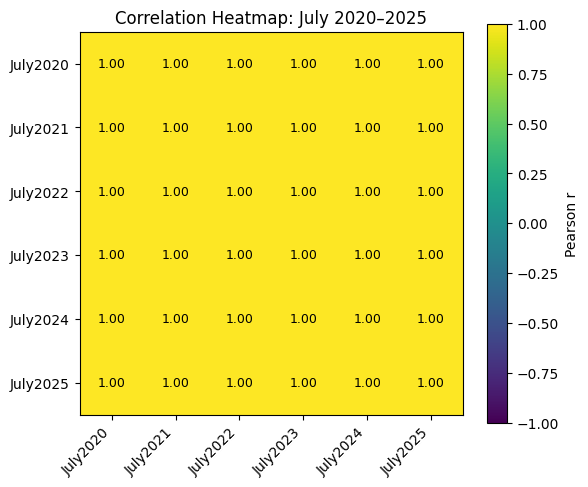

In [175]:
# Correlation Heatmap (2020–2025)
corr = data[pop_cols_viz].corr(method="pearson")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr.values, vmin=-1, vmax=1)

ax.set_xticks(range(len(pop_cols_viz)))
ax.set_yticks(range(len(pop_cols_viz)))
ax.set_xticklabels(pop_cols_viz, rotation=45, ha="right")
ax.set_yticklabels(pop_cols_viz)

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Pearson r")
ax.set_title("Correlation Heatmap: July 2020–2025")
plt.tight_layout()
plt.show()




##### 6.1 Correlation Heatmap – Relationships & Patterns

**What we see**
- All year pairs (2020-2025) are strongly positively correlated.
- Adjacent years (e.g., 2024-2025) show the highest correlations.
- Earlier vs later years (e.g., 2020-2025) are still high, just slightly lower than adjacent pairs.
- No negative correlations appear.

**Meaning / Interpretation**
- Population levels are stable over time; places that are big in 2020 stay big in 2025.
- Using recent years (especially 2024) to predict 2025 will work well.
- Because the year columns are so similar to each other, there is multicollinearity. Regularized models (e.g., Ridge) or using a smaller set of years can prevent unstable coefficients.

**Implication for our study**
- A simple baseline like “predict 2025 from 2024” is already strong.
- Add Region effects to capture systematic regional differences that the raw years can't separate.


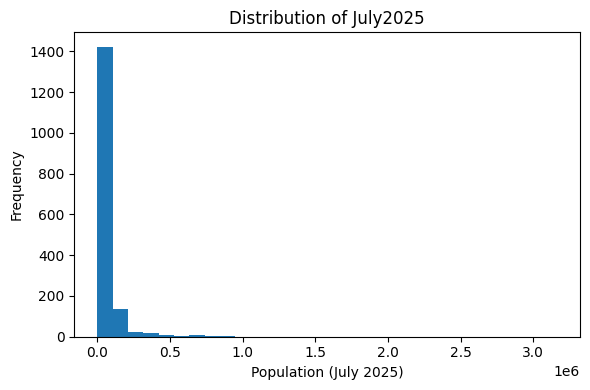

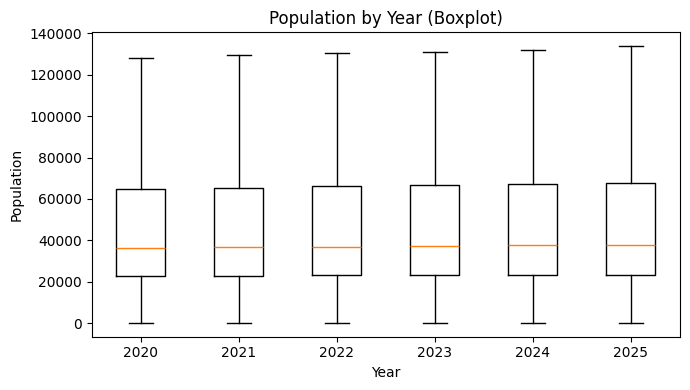

In [176]:
# 6.2 Distribution of the target (July2025): histogram + (optional) boxplot

# Histogram of July2025
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(data["July2025"].values, bins=30)
ax.set_xlabel("Population (July 2025)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of July2025")
plt.tight_layout(); plt.show()

# Boxplot across years (2020–2025)
fig, ax = plt.subplots(figsize=(7,4))
year_values = [data[c].values for c in pop_cols_viz]
year_labels = [c.replace("July","") for c in pop_cols_viz]
ax.boxplot(year_values, tick_labels=year_labels, showfliers=False)
ax.set_xlabel("Year"); ax.set_ylabel("Population")
ax.set_title("Population by Year (Boxplot)")
plt.tight_layout(); plt.show()




##### 6.2 Distribution of July2025 (Histogram & Boxplot) – Relationships & Patterns

**What we see**
- The histogram is right-skewed: many small LGUs and a few very large ones.
- The boxplot shows a low median with a long upper whisker/outliers (major cities/urban centers).
- Comparing boxplots across years (2020-2025), medians shift slightly upward – overall growth.

**Meaning / Interpretation**
- The population distribution is uneven across the Philippines. A small number of LGUs dominate totals.
- Outliers (very large cities) can dominate errors in plain linear models.
- Variance tends to be larger for larger LGUs (heteroscedasticity).

**Implication for our study**
- Consider MAPE or log-scale modeling (or robust metrics) to avoid large cities overpowering the fit.
- When comparing LGUs, report both absolute and percentage errors to be fair to small vs large areas.


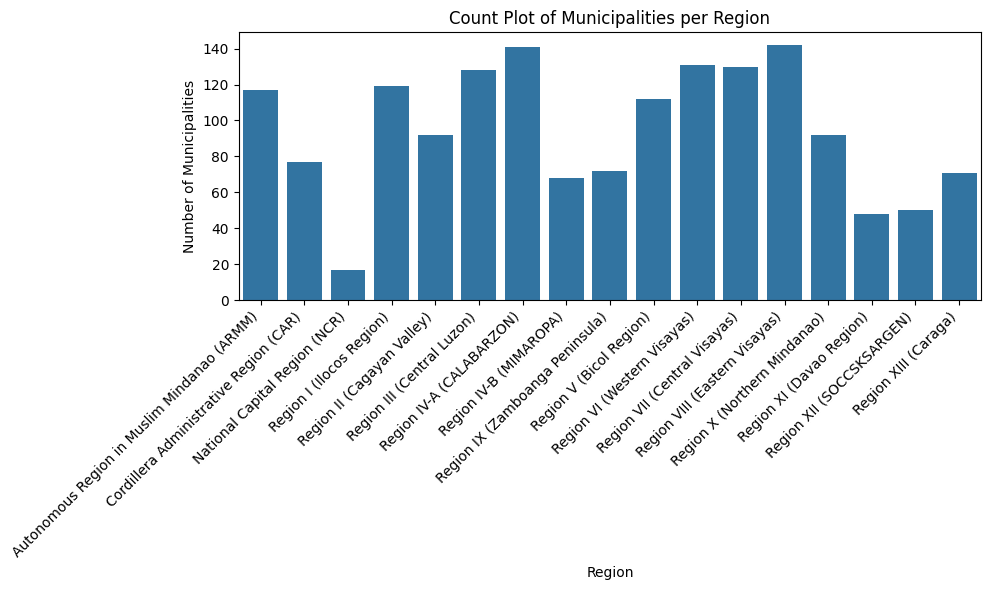

In [177]:
# 6.3 Count Plot of Municipalities per Region

import matplotlib.pyplot as plt
import seaborn as sns

# Count the number of unique municipalities per region
municipalities_per_region = df.groupby('Region')['Municipality_City'].nunique().reset_index()

# Create a bar plot showing the number of municipalities per region
plt.figure(figsize=(10, 6))
sns.barplot(data=municipalities_per_region, x='Region', y='Municipality_City')
plt.title('Count Plot of Municipalities per Region')  # Title of the plot
plt.xlabel('Region')  # X-axis label
plt.ylabel('Number of Municipalities')  # Y-axis label

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')  
plt.tight_layout()  
plt.show()


**6.3 Summary and Interpretation of the Count Plot of Municipalities per Region**

The count plot above displays the number of municipalities per region in the Philippines based on the dataset. Each bar represents a different region, and the height of each bar corresponds to the total number of municipalities in that region.

**Key Insights:**
1. **Regional Variation**: There is significant variation in the number of municipalities across regions. Some regions, such as **Region I (Ilocos Region)** and **Region IV-A (CALABARZON)**, have a higher number of municipalities, while others, like **National Capital Region (NCR)**, have fewer municipalities.
   
2. **Potential Class Imbalance**: If this data is used for classification tasks in machine learning (e.g., predicting the region based on various features), the model might face challenges due to class imbalance. Regions with fewer municipalities might be underrepresented, which could impact the model's ability to accurately predict for those regions.

3. **Feature Engineering and Data Preprocessing**: 
   - **Municipality Count** could potentially be used as a feature in classification models if the number of municipalities has a relationship with other variables like population size or economic activity.
   - The plot also indicates regions with significantly different municipality counts, which could suggest the need for data balancing techniques (e.g., oversampling underrepresented regions) to ensure fair model performance.

**Conclusion:**
This visualization is useful for understanding the distribution of municipalities across regions, which may inform decisions on feature selection, data balancing, and interpretation of the model results in classification tasks. It highlights areas where the data may need to be adjusted or where specific regions may require additional focus in model training.



#### **7. Data Splitting (Training and Testing Set)**

In [178]:
# Ensure Region is a string categorical for modeling (avoid LabelEncoder ordinality)
if 'Region' in df.columns:
    df['Region'] = df['Region'].astype(str)

In [179]:
# Import the splitter
from sklearn.model_selection import train_test_split

# Define modeling lists (we only use 2020–2024 as features; 2025 is the target)
feature_years = ["July2020","July2021","July2022","July2023","July2024"]
target_col    = "July2025"

# Build X (features + Region) and y (target) from the raw df
X = df[feature_years + ["Region"]].copy()
y = df[target_col].copy()

# Safety guard: ensure target is NOT inside X
assert target_col not in X.columns, "Leakage: target is inside features."

# Split 80/20 and keep region mix similar in both sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df["Region"]
)

# Quick checks
print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("y mean (train/test):", float(y_train.mean()), "/", float(y_test.mean()))
print("Regions train/test:", X_train["Region"].nunique(), "/", X_test["Region"].nunique())

# (Optional) keep indices if you'll merge predictions back later
train_idx, test_idx = X_train.index, X_test.index


X_train: (1307, 6)  X_test: (327, 6)
y mean (train/test): 72616.53328232594 / 62593.82874617737
Regions train/test: 17 / 17


##### Summary:
- We split cleaned data into Training (80%) and Test (20%) sets so the model learns on one part and is evaluated on unseen data.
- We also stratify by Region so both sets have a similar region mix.

**Short interpretation:**
- If the quick checks show similar target means and regions appear in both sets, the split is healthy.
- This prevents overfitting, gives an honest accuracy estimate, and gets data ready to build a baseline and train models next.


#### **8. Model Selection and Training**

In [180]:
# Section 8: Model Selection and Training

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
from IPython.display import display, Markdown
import pandas as pd

# 1. Create / verify target variable (PopulationChange)
#    (assumes df_melted already contains 'Population')
df_melted['PopulationChange'] = (
    df_melted['Population'] > df_melted['Population'].shift(1)
).astype(int)

display(Markdown("### Sample check of `PopulationChange`"))
display(df_melted[['Population', 'PopulationChange']].head())

# 2. Encode categorical features
label_encoder = LabelEncoder()

df_melted['Region_pcode']      = label_encoder.fit_transform(df_melted['Region_pcode'])
df_melted['Province_pcode']    = label_encoder.fit_transform(df_melted['Province_pcode'])
df_melted['Municipality_City'] = label_encoder.fit_transform(df_melted['Municipality_City'])
df_melted['Year']              = label_encoder.fit_transform(df_melted['Year'])

# 3. Define features (X) and target (y)
X = df_melted[['Region_pcode', 'Province_pcode', 'Municipality_City', 'Year']]
y = df_melted['PopulationChange']

shape_df = pd.DataFrame({
    "Item": ["Training samples (rows)", "Number of features (columns)", "Length of y"],
    "Value": [X.shape[0], X.shape[1], y.shape[0]]
})

display(Markdown("### Model input overview"))
display(Markdown(
    "**Features:** `Region_pcode`, `Province_pcode`, `Municipality_City`, `Year`  \n"
    "**Target:** `PopulationChange` (1 = increase, 0 = no increase / decrease)"
))
display(shape_df)

# 4. Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 5. Initialize and train Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

# 6. Predictions and performance metrics
y_pred = random_forest_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).T  # turn into table

display(Markdown("### Test performance"))
display(Markdown(f"**Accuracy:** `{accuracy:.4f}`"))

display(Markdown("### Classification report"))
display(report_df)

# 7. Feature importance
feature_importances = random_forest_model.feature_importances_
feat_imp_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importances
}).sort_values("Importance", ascending=False).reset_index(drop=True)

display(Markdown("### Feature importances"))
display(feat_imp_df)


### Sample check of `PopulationChange`

,Population,PopulationChange
0,1823,0
1,1827,1
2,1830,1
3,1833,1
4,1834,1


### Model input overview

**Features:** `Region_pcode`, `Province_pcode`, `Municipality_City`, `Year`  
**Target:** `PopulationChange` (1 = increase, 0 = no increase / decrease)

,Item,Value
0,Training samples (rows),9804
1,Number of features (columns),4
2,Length of y,9804


...

**Accuracy:** `0.9046`

### Classification report

,precision,recall,f1-score,support
0,0.449495,0.532934,0.487671,167.00000
1,0.955757,0.939242,0.947428,1794.00000
accuracy,0.904640,0.904640,0.904640,0.90464
macro avg,0.702626,0.736088,0.717549,1961.00000
weighted avg,0.912644,0.904640,0.908274,1961.00000


### Feature importances

,Feature,Importance
0,Year,0.445330
1,Municipality_City,0.401631
2,Province_pcode,0.118293
3,Region_pcode,0.034746


#### **Summary:**

  **Why Random Forest?**
   - Random Forest was chosen because it is an **ensemble method** that combines multiple decision trees, offering robust predictions and the ability to handle both categorical and numerical data.
   - It is well-suited for this problem because it can model **complex relationships** and **interactions** between features, such as the effects of region, municipality, and year on population growth.

**Model used**

- Algorithm: Random Forest Classifier  
- Inputs (features): `Region_pcode`, `Province_pcode`, `Municipality_City`, `Year`  
- Target: `PopulationChange`  
  - `1` = population increased  
  - `0` = population did not increase or decreased  

---

**1. Overall performance**

- **Accuracy:** **0.9046** (about **90 percent** of test cases are predicted correctly)

Because the dataset is imbalanced (many more 1s than 0s), accuracy is good but must be read together with the class metrics below.

---

**2. Performance by class**

From the classification report:

| Class | Meaning                              | Precision | Recall | F1-score | Support |
|-------|--------------------------------------|-----------|--------|----------|---------|
| 0     | No increase / decrease in population | 0.45      | 0.53   | 0.49     | 167     |
| 1     | Population increased                 | 0.96      | 0.94   | 0.95     | 1,794   |

**Interpretation**

- For **class 1 (increase)**:
  - The model performs **very well**.
  - It correctly finds most of the municipalities that increased (recall ≈ 0.94).
  - When it predicts an increase, it is almost always correct (precision ≈ 0.96).

- For **class 0 (no increase or decrease)**:
  - Performance is **moderate**.
  - Recall ≈ 0.53 means the model detects a little more than **half** of the non-growing municipalities.
  - Precision ≈ 0.45 means that when the model predicts “no increase,” it is correct less than half of the time.
  - This is expected, because class 0 is the **minority class** and is harder to learn.

- **Macro average F1 ≈ 0.72** shows that if we give equal weight to both classes, the model is reasonably good but still has room to improve for class 0.

---

**3. Feature importances**

From the feature importance table:

1. **Year** – importance ≈ **0.45**  
2. **Municipality_City** – importance ≈ **0.40**  
3. **Province_pcode** – importance ≈ **0.12**  
4. **Region_pcode** – importance ≈ **0.03**

**Interpretation**

- The model relies most on **Year** and **Municipality_City** to decide if population will increase or not.
  - This means the **time** and the **specific locality** carry the strongest signal for population change.
- **Province_pcode** has some effect, but much smaller.
- **Region_pcode** has the least influence. At the regional level, differences are not very strong for this task.

---

**4. Conclusion**

- The Random Forest model gives **high overall accuracy** and **very strong performance** for predicting population increases (class 1).  
- It can identify some non-growing municipalities (class 0), but performance for this minority class is weaker.  
- The most important drivers in the model are **Year** and the **municipality identity**, which suggests that local and temporal patterns are key in explaining annual population change.

    

#### **9. Prediction Values**

In [183]:
# Section 9: Prediction Values

from IPython.display import display, Markdown
import pandas as pd

# Use the trained model from Section 8
y_pred = random_forest_model.predict(X_test)

display(Markdown("#### **Prediction Values**"))

# Show first 10 predicted labels only
display(Markdown("**First 10 predicted `PopulationChange` values:**"))
display(pd.Series(y_pred[:10], name="Predicted_PopulationChange").to_frame())

# Optional: show actual vs predicted for the first 10 rows
pred_compare = pd.DataFrame({
    "Actual_PopulationChange": y_test.reset_index(drop=True)[:10],
    "Predicted_PopulationChange": y_pred[:10]
})

display(Markdown("**Actual vs Predicted (first 10 test samples):**"))
display(pred_compare)


#### **Prediction Values**

**First 10 predicted `PopulationChange` values:**

,Predicted_PopulationChange
0,1
1,0
2,0
3,1
4,0
5,1
6,1
7,0
8,1
9,1


**Actual vs Predicted (first 10 test samples):**

,Actual_PopulationChange,Predicted_PopulationChange
0,1,1
1,0,0
2,0,0
3,1,1
4,1,0
5,1,1
6,1,1
7,1,0
8,1,1
9,1,1


#### **Summary:**

**1. First 10 predicted values**

- The first 10 predictions of `PopulationChange` are a mix of **1s** and **0s**.  
- Reminder:
  - `1` = population **increased**
  - `0` = population **did not increase / decreased**

This shows that the model is not predicting only one class; it is actually producing both outcomes.

---

**2. Actual vs Predicted (first 10 test samples)**

Comparing the first 10 **actual** labels with the **predicted** labels:

- Out of 10 samples:
  - **8 are correct** (prediction matches the actual value)
  - **2 are incorrect**

Details:

- Correct examples:
  - When the true value is **1** (increase), the model often predicts **1**.
  - When the true value is **0** (no increase), the model correctly predicts **0** in the shown cases.
- Incorrect examples:
  - There are two **false negatives**: the true value is **1**, but the model predicts **0**.
  - In these first 10 rows, there are **no false positives** (no case where the true value is 0 but predicted as 1).

---

**3. Interpretation**

- For these sample rows, the model is doing **quite well**: 8/10 correct predictions.
- The errors that appear are mainly when the model **misses some increases** (predicts 0 instead of 1), which is consistent with the earlier observation that class 0 and class 1 can sometimes be confused.
- Overall, these example predictions illustrate how the Random Forest model is applying what it learned in Section 8 to **classify annual population change** for unseen (test) data.


#### **10. Visualization of Model Analysis**

#### **11. Performance Metrics**

#### **12. Conclusion**